In [1]:
from google.colab import files
uploaded = files.upload()

Saving telecomx_clean_labeled.csv to telecomx_clean_labeled.csv


In [2]:
import pandas as pd

df = pd.read_csv("telecomx_clean_labeled.csv")

print("Dataset cargado correctamente ✅")
df.head()

Dataset cargado correctamente ✅


,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,cuentas_diarias,churn_flag
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   seniorcitizen     7043 non-null   int64  
 4   partner           7043 non-null   object 
 5   dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   phoneservice      7043 non-null   object 
 8   multiplelines     7043 non-null   object 
 9   internetservice   7043 non-null   object 
 10  onlinesecurity    7043 non-null   object 
 11  onlinebackup      7043 non-null   object 
 12  deviceprotection  7043 non-null   object 
 13  techsupport       7043 non-null   object 
 14  streamingtv       7043 non-null   object 
 15  streamingmovies   7043 non-null   object 
 16  contract          7043 non-null   object 


In [4]:
df.describe()

,seniorcitizen,tenure,charges_monthly,charges_total,cuentas_diarias,churn_flag
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,2.158723,0.265370
std,0.368612,24.559481,30.090047,2266.794470,1.003002,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.608333,0.000000
25%,0.000000,9.000000,35.500000,398.550000,1.183333,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,2.345000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,2.995000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,3.958333,1.000000


In [5]:
# Eliminar columnas irrelevantes
df = df.drop(columns=['customerid', 'churn'])

# Confirmar columnas restantes
print("Columnas actuales:")
print(df.columns.tolist())

Columnas actuales:
['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'charges_monthly', 'charges_total', 'cuentas_diarias', 'churn_flag']


In [6]:
# Proporción de cancelación
df['churn_flag'].value_counts(normalize=True)

,proportion
churn_flag,
0,0.73463
1,0.26537


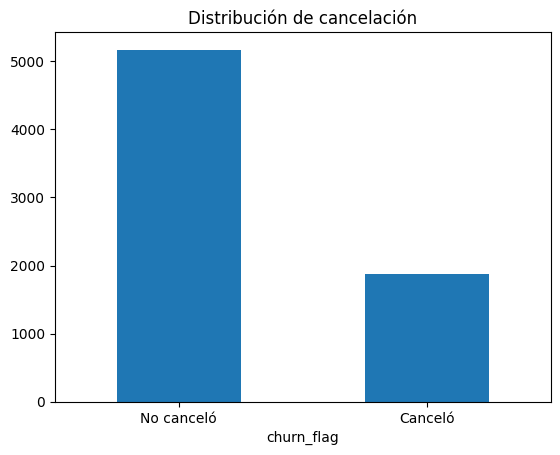

In [7]:
import matplotlib.pyplot as plt

df['churn_flag'].value_counts().plot(kind='bar')
plt.title("Distribución de cancelación")
plt.xticks([0,1], ['No canceló', 'Canceló'], rotation=0)
plt.show()

In [8]:
# Separar variables predictoras y objetivo
X = df.drop(columns='churn_flag')
y = df['churn_flag']

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (7043, 20)
Shape de y: (7043,)


In [9]:
# Aplicar One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape después de encoding:", X_encoded.shape)
X_encoded.head()

Shape después de encoding: (7043, 24)


,seniorcitizen,tenure,charges_monthly,charges_total,cuentas_diarias,gender_Male,partner_Yes,dependents_Yes,phoneservice_Yes,multiplelines_Yes,...,deviceprotection_Yes,techsupport_Yes,streamingtv_Yes,streamingmovies_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,9,65.6,593.30,2.186667,False,True,True,True,False,...,False,True,True,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,True,False,False,True,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,True,False,False,True,False,...,True,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,True,True,False,True,False,...,True,False,True,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,False,True,False,True,False,...,False,True,True,False,False,False,True,False,False,True


In [10]:
from sklearn.model_selection import train_test_split

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantiene proporción de cancelación
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5634, 24)
Prueba: (1409, 24)


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Escalar datos
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear modelo
log_model = LogisticRegression(max_iter=1000)

# Entrenar
log_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_log = log_model.predict(X_test_scaled)

print("Modelo entrenado correctamente ✅")

Modelo entrenado correctamente ✅


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Accuracy
acc = accuracy_score(y_test, y_pred_log)
print("Accuracy:", acc)

# Reporte completo
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_log))

# Matriz de confusión
print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.7927608232789212

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Matriz de confusión:

[[922 113]
 [179 195]]


Random Forest


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

# Entrenar (sin escalado)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

print("Random Forest entrenado correctamente ✅")

Random Forest entrenado correctamente ✅


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest:", acc_rf)

# Reporte completo
print("\nReporte Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
print("\nMatriz de confusión RF:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy Random Forest: 0.7863733144073811

Reporte Random Forest:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409


Matriz de confusión RF:

[[929 106]
 [195 179]]


In [15]:
import pandas as pd

# Extraer coeficientes
coef_df = pd.DataFrame({
    "Variable": X_encoded.columns,
    "Coeficiente": log_model.coef_[0]
})

# Ordenar por impacto
coef_df = coef_df.sort_values(by="Coeficiente", ascending=False)

coef_df.head(10)

,Variable,Coeficiente
3,charges_total,0.701014
10,internetservice_Fiber optic,0.572148
16,streamingtv_Yes,0.196128
9,multiplelines_Yes,0.193866
22,paymentmethod_Electronic check,0.191104
20,paperlessbilling_Yes,0.178717
17,streamingmovies_Yes,0.144152
0,seniorcitizen,0.073222
14,deviceprotection_Yes,0.026186
23,paymentmethod_Mailed check,0.012308


In [16]:
coef_df.tail(10)

,Variable,Coeficiente
7,dependents_Yes,-0.069380
8,phoneservice_Yes,-0.075242
12,onlinesecurity_Yes,-0.114410
15,techsupport_Yes,-0.156918
2,charges_monthly,-0.269944
4,cuentas_diarias,-0.269944
18,contract_One year,-0.279734
11,internetservice_No,-0.516728
19,contract_Two year,-0.581427
1,tenure,-1.429993


In [17]:
coef_df.sort_values(by="Coeficiente", ascending=True).head(10)

,Variable,Coeficiente
1,tenure,-1.429993
19,contract_Two year,-0.581427
11,internetservice_No,-0.516728
18,contract_One year,-0.279734
4,cuentas_diarias,-0.269944
2,charges_monthly,-0.269944
15,techsupport_Yes,-0.156918
12,onlinesecurity_Yes,-0.114410
8,phoneservice_Yes,-0.075242
7,dependents_Yes,-0.069380
